# 01 · MDPs and dynamic programming

[Course README](../README.md) · README topics **3–16**

**Goal.** Build a finite MDP, evaluate a policy with both a linear system and Bellman backups, and implement policy iteration and value iteration.

**How to run:** select **Restart Kernel and Run All**. Every required function is defined
in this notebook; run cells in order. The defaults are small CPU experiments, not benchmark
training runs. Install the root `requirements.txt` once before opening Jupyter.
No cells install packages, download data, or require account credentials.

<img src="../assets/diagrams/policy-iteration.svg" width="760" alt="Overview of MDPs and dynamic programming">

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/notebooks/01_mdp_dynamic_programming.ipynb)

[Reproducibility guide](../REPRODUCIBILITY.md) · [Integrated comparison lab](08_one_problem_many_algorithms.ipynb)

## 1. The problem: plan deliveries with a complete map

A robot moves on a **4 × 4 grid**. Its state is a cell index; the four actions are up,
right, down, and left. An action into a wall leaves the robot in the same cell.
Every transition from a nonterminal state costs **−1**, including entry into the goal.
The lower-right cell is terminal. Its outgoing model transition is a zero-reward self-loop,
which is a mathematical convenience: a real episode stops on entry.

We use discount **γ = 0.95**. This is a separate toy task from the README's +10 delivery example.
The model is known, so we can plan without collecting samples.

**Analogy:** work out a route at a desk using a complete road map. Policy evaluation asks
how good the current instructions are; policy improvement changes those instructions.

The array `P[s, a, next_s]` stores transition probabilities, and `R[s, a]` stores expected
immediate rewards. All calculations in this lesson are tabular and exact up to numerical tolerance.

In [1]:
import platform
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
INK, GOLD, SAGE, PLUM, PAPER = '#292332', '#AF824A', '#768165', '#87708C', '#F5F1E8'
plt.rcParams.update({
    'figure.figsize': (9, 4), 'figure.dpi': 110,
    'figure.facecolor': PAPER, 'axes.facecolor': PAPER,
    'text.color': INK, 'axes.labelcolor': INK, 'axes.edgecolor': INK,
    'xtick.color': INK, 'ytick.color': INK,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=[GOLD, SAGE, PLUM, INK]),
    'axes.grid': True, 'grid.alpha': 0.18,
})
np.set_printoptions(precision=3, suppress=True)
print(f'Python {platform.python_version()} | NumPy {np.__version__}')

Python 3.12.4 | NumPy 2.5.3


In [2]:
ROWS = COLS = 4
N_STATES, N_ACTIONS = ROWS * COLS, 4
GOAL, GAMMA = N_STATES - 1, 0.95
DELTAS = [(-1, 0), (0, 1), (1, 0), (0, -1)]
ARROWS = ['↑', '→', '↓', '←']
P = np.zeros((N_STATES, N_ACTIONS, N_STATES))
R = -np.ones((N_STATES, N_ACTIONS))
for s in range(N_STATES):
    row, col = divmod(s, COLS)
    for a, (dr, dc) in enumerate(DELTAS):
        next_row = np.clip(row + dr, 0, ROWS - 1)
        next_col = np.clip(col + dc, 0, COLS - 1)
        next_s = int(next_row * COLS + next_col)
        P[s, a, GOAL if s == GOAL else next_s] = 1.0
R[GOAL] = 0.0
assert np.allclose(P.sum(axis=-1), 1.0)
print(f'{N_STATES} states, {N_ACTIONS} actions; goal = {GOAL}')

16 states, 4 actions; goal = 15


## 2. A Bellman backup is a one-step forecast

For each action, add its reward to the discounted expected value of the next state:

```text
Q_from_V(s, a) = R(s, a) + gamma * sum_next P(next | s, a) * V(next)
```

Evaluation averages these targets under a fixed policy. Optimality takes their maximum.
With a zero initial value table, every nonterminal first backup is −1.

In [3]:
def action_values(values):
    """One-step lookahead for all state-action pairs; shape (states, actions)."""
    return R + GAMMA * np.einsum('san,n->sa', P, values)

def evaluate_policy(policy, tolerance=1e-10, max_sweeps=10_000):
    """Evaluate a fixed stochastic policy by synchronous expectation backups."""
    values = np.zeros(N_STATES)
    changes = []
    for _ in range(max_sweeps):
        new_values = np.sum(policy * action_values(values), axis=1)
        changes.append(np.max(np.abs(new_values - values)))
        values = new_values
        if changes[-1] < tolerance:
            return values, np.array(changes)
    raise RuntimeError('Policy evaluation did not converge')

random_policy = np.full((N_STATES, N_ACTIONS), 1 / N_ACTIONS)
v_random, changes = evaluate_policy(random_policy)
assert np.all(action_values(np.zeros(N_STATES))[:-1] == -1)
print('Value under a uniformly random policy:\n', v_random.reshape(ROWS, COLS))

Value under a uniformly random policy:
 [[-16.469 -16.097 -15.488 -14.96 ]
 [-16.097 -15.513 -14.456 -13.372]
 [-15.488 -14.456 -12.286  -9.303]
 [-14.96  -13.372  -9.303   0.   ]]


## 3. Verify evaluation with an independent calculation

For a fixed policy, combine the action-conditioned transitions into `P_pi` and rewards
into `r_pi`. Bellman's equation becomes `(I − γ P_pi) V = r_pi`. Solving that linear
system provides an independent check of the iterative implementation.

Maximum iterative / linear-solve difference: 1.3055938552497537e-09


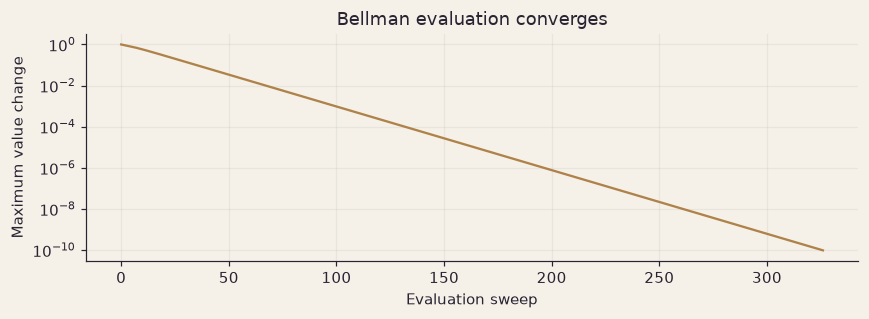

In [4]:
p_pi = np.einsum('sa,san->sn', random_policy, P)
r_pi = np.sum(random_policy * R, axis=1)
v_linear = np.linalg.solve(np.eye(N_STATES) - GAMMA * p_pi, r_pi)
assert np.allclose(v_random, v_linear, atol=1e-8)
assert abs(v_random[GOAL]) < 1e-10
print('Maximum iterative / linear-solve difference:', np.max(np.abs(v_random - v_linear)))

fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(changes)
ax.set(xlabel='Evaluation sweep', ylabel='Maximum value change', title='Bellman evaluation converges')
plt.tight_layout(); plt.show()

## 4. Policy iteration: evaluate, improve, repeat

We first evaluate a stochastic policy. We then replace it with one greedy action per
state. A consistent tie rule is important: retain the current deterministic choice if it
is already a maximizing action, rather than switching between equally good actions.
The terminal state's action has no behavioral meaning, so we fix it to action zero.

In [5]:
def policy_iteration():
    """Return an optimal value table, deterministic actions, and improvement count."""
    policy = random_policy.copy()
    actions = np.zeros(N_STATES, dtype=int)
    for iteration in range(1, 100):
        values, _ = evaluate_policy(policy)
        q = action_values(values)
        greedy = q.argmax(axis=1)
        if iteration > 1:
            tied = np.isclose(q[np.arange(N_STATES), actions], q.max(axis=1), atol=1e-9, rtol=0)
            greedy[tied] = actions[tied]
        greedy[GOAL] = 0
        improved = np.eye(N_ACTIONS)[greedy]
        stable = np.array_equal(policy, improved)
        policy, actions = improved, greedy
        if stable:
            return values, actions, iteration
    raise RuntimeError('Policy iteration did not stabilize')

v_pi, policy_pi, n_improvements = policy_iteration()
print('Policy iteration improvements:', n_improvements)
print(v_pi.reshape(ROWS, COLS))

Policy iteration improvements: 2
[[-5.298 -4.524 -3.71  -2.853]
 [-4.524 -3.71  -2.853 -1.95 ]
 [-3.71  -2.853 -1.95  -1.   ]
 [-2.853 -1.95  -1.     0.   ]]


## 5. Value iteration: improve at every sweep

Value iteration uses `max` in every backup instead of fully evaluating one policy between
improvements. Both methods solve this finite discounted MDP. Their intermediate policies
and iteration counts differ, and iteration counts alone are not a fair measure of compute cost.

In [6]:
def value_iteration(tolerance=1e-10, max_sweeps=10_000):
    """Apply Bellman optimality backups until values stabilize."""
    values = np.zeros(N_STATES)
    for sweep in range(1, max_sweeps + 1):
        new_values = action_values(values).max(axis=1)
        change = np.max(np.abs(new_values - values))
        values = new_values
        if change < tolerance:
            return values, action_values(values).argmax(axis=1), sweep
    raise RuntimeError('Value iteration did not converge')

v_vi, policy_vi, n_sweeps = value_iteration()
# A shortest path has Manhattan distance d and d rewards of -1.
distances = np.array([(ROWS - 1 - s // COLS) + (COLS - 1 - s % COLS) for s in range(N_STATES)])
v_expected = -(1 - GAMMA ** distances) / (1 - GAMMA)
assert np.allclose(v_pi, v_vi, atol=1e-8)
assert np.allclose(v_vi, v_expected, atol=1e-8)
assert np.all(v_pi >= v_random - 1e-8)
print('Value iteration sweeps:', n_sweeps)
print('Start value:', round(v_vi[0], 4), '| shortest-path length:', distances[0])

Value iteration sweeps: 7
Start value: -5.2982 | shortest-path length: 6


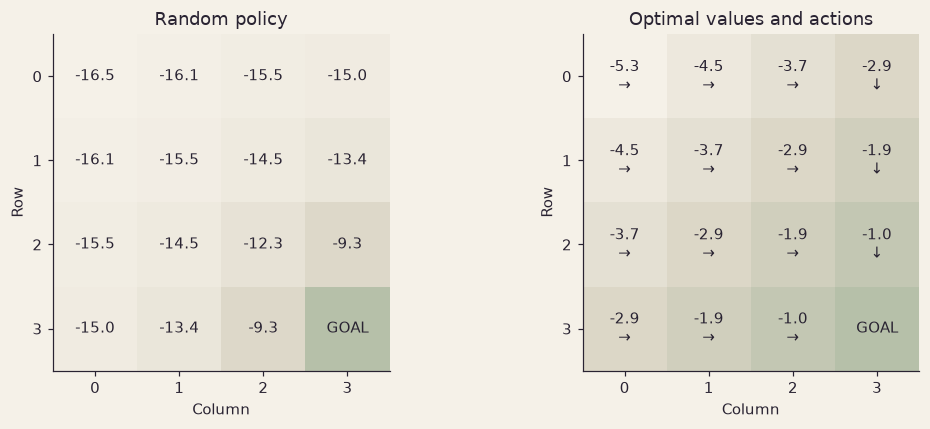

In [7]:
from matplotlib.colors import LinearSegmentedColormap
course_map = LinearSegmentedColormap.from_list('course', [PAPER, '#DAD5C5', '#B6C0A9'])
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, values, title in zip(axes, [v_random, v_vi], ['Random policy', 'Optimal values and actions']):
    ax.imshow(values.reshape(ROWS, COLS), cmap=course_map, interpolation='nearest')
    for s in range(N_STATES):
        row, col = divmod(s, COLS)
        label = 'GOAL' if s == GOAL else f'{values[s]:.1f}'
        if title.startswith('Optimal') and s != GOAL: label += '\n' + ARROWS[policy_vi[s]]
        ax.text(col, row, label, ha='center', va='center', color=INK)
    ax.set(title=title, xticks=range(COLS), yticks=range(ROWS), xlabel='Column', ylabel='Row')
    ax.grid(False)
plt.tight_layout(); plt.show()

The optimal map should point toward the goal while avoiding wasted wall moves. Several
shortest routes can tie; a different arrow pattern can still be optimal. Negative values
are expected because every move costs something. Values close to zero indicate fewer
remaining costs, not a failure to learn.

## Exercises

1. Change γ to 0.5 and rerun. Why do distant states become less negative?
2. Give a wall move reward −3. Which action values change?
3. Replace one deterministic move with two equally likely next states. Preserve row sums in P.
4. Compare the number of backups performed by the two planning algorithms.

<details>
<summary>Hints and expected reasoning — open after trying the exercises</summary>

1. Future costs receive less weight.
2. Wall actions become worse; remember to change R before solving.
3. Set the original probability to zero before distributing mass. The shortest-path closed-form check no longer applies to this changed MDP.
4. Count evaluation sweeps times states and actions; improvement counts alone hide work.

</details>

## What to remember

DP uses a known model. Evaluation averages under a policy; improvement chooses better actions. Independent analytical solutions make small environments valuable debugging tools.

## Further reading

- Sutton and Barto, [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html). Chapters 3–4.

## Experiment summary

These values are computed from this run. Compare the evaluation setting and seeds before interpreting a difference; training reward, success, and estimation error answer different questions.

In [8]:
from IPython.display import Markdown, display
def result_table(headers, rows):
    clean = lambda value: str(value).replace('|', '&#124;').replace('\n', '<br>')
    display(Markdown('| ' + ' | '.join(headers) + ' |\n|' + '|'.join(['---'] * len(headers)) + '|\n' +
                     '\n'.join('| ' + ' | '.join(map(clean, row)) + ' |' for row in rows)))
rows = [['Iterative vs linear solve max error', f'{np.max(np.abs(v_random-v_linear)):.3g}'],
        ['Policy iteration improvements', n_improvements], ['Value iteration sweeps', n_sweeps],
        ['Optimal start value', f'{v_vi[0]:.4f}'], ['Shortest path length', distances[0]]]
result_table(['Measure', 'Result'], rows)

| Measure | Result |
|---|---|
| Iterative vs linear solve max error | 1.31e-09 |
| Policy iteration improvements | 2 |
| Value iteration sweeps | 7 |
| Optimal start value | -5.2982 |
| Shortest path length | 6 |

[Next notebook →](02_mc_vs_td.ipynb)